In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
PROCESSED = Path('../data/processed')

In [2]:
df = pd.read_csv(PROCESSED / 'match_features.csv', parse_dates=['date'])
print(df.shape)
df.head()

(2994, 20)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,home_rank,home_points,away_rank,away_points,home_elo,away_elo,rank_diff,point_diff,elo_diff,is_friendly
0,2022-12-20,Cambodia,Philippines,3.0,2.0,AFF Championship,Phnom Penh,Cambodia,False,1,177.0,948.62,133.0,1115.13,NaN,NaN,44.0,-166.51,NaN,0
1,2022-12-21,Myanmar,Malaysia,0.0,1.0,AFF Championship,Yangon,Myanmar,False,-1,158.0,1007.89,146.0,1062.32,NaN,NaN,12.0,-54.43,NaN,0
2,2022-12-21,Laos,Vietnam,0.0,6.0,AFF Championship,Vientiane,Laos,False,-1,187.0,905.51,96.0,1226.65,NaN,NaN,91.0,-321.14,NaN,0
3,2022-12-23,Oman,Syria,2.0,1.0,Friendly,Dubai,United Arab Emirates,True,1,75.0,1321.24,90.0,1251.46,NaN,NaN,-15.0,69.78,NaN,1
4,2022-12-23,Indonesia,Cambodia,2.0,1.0,AFF Championship,Jakarta,Indonesia,False,1,151.0,1033.90,177.0,946.66,NaN,NaN,-26.0,87.24,NaN,0


In [3]:
# rolling stats for each team over their last 5 games
# we sort by date first so the window always looks backwards
df = df.sort_values('date').reset_index(drop=True)

def rolling_team_stats(df, team_col, score_col, concede_col, suffix):
    stats = []
    for team in df[team_col].unique():
        mask   = df[team_col] == team
        team_df = df[mask].copy()
        team_df[f'goals_scored_{suffix}']   = team_df[score_col].shift(1).rolling(5, min_periods=1).mean()
        team_df[f'goals_conceded_{suffix}']  = team_df[concede_col].shift(1).rolling(5, min_periods=1).mean()
        stats.append(team_df[['date', team_col, f'goals_scored_{suffix}', f'goals_conceded_{suffix}']])
    return pd.concat(stats).sort_values('date')

home_stats = rolling_team_stats(df, 'home_team', 'home_score', 'away_score', 'home')
away_stats = rolling_team_stats(df, 'away_team', 'away_score', 'home_score', 'away')

df = df.merge(home_stats, on=['date', 'home_team'], how='left')
df = df.merge(away_stats, on=['date', 'away_team'], how='left')

print(df[['home_team', 'away_team', 'goals_scored_home', 'goals_conceded_home',
          'goals_scored_away', 'goals_conceded_away']].head(10))

   home_team    away_team  goals_scored_home  goals_conceded_home  \
0   Cambodia  Philippines                NaN                  NaN   
1    Myanmar     Malaysia                NaN                  NaN   
2       Laos      Vietnam                NaN                  NaN   
3       Oman        Syria                NaN                  NaN   
4  Indonesia     Cambodia                NaN                  NaN   
5  Singapore      Myanmar                NaN                  NaN   
6   Malaysia         Laos                NaN                  NaN   
7   Thailand  Philippines                NaN                  NaN   
8       Laos    Singapore                0.0                  6.0   
9    Vietnam     Malaysia                NaN                  NaN   

   goals_scored_away  goals_conceded_away  
0                NaN                  NaN  
1                NaN                  NaN  
2                NaN                  NaN  
3                NaN                  NaN  
4                NaN

In [4]:
# drop rows where we don't have elo for either team
# this filters out non-WC nations naturally
before = len(df)
df = df.dropna(subset=['home_elo', 'away_elo'])
print(f'dropped {before - len(df)} rows missing elo')
print(f'remaining: {len(df)} matches')

dropped 2670 rows missing elo
remaining: 326 matches


In [5]:
# final feature set
features = [
    'rank_diff',
    'point_diff',
    'elo_diff',
    'is_friendly',
    'goals_scored_home',
    'goals_conceded_home',
    'goals_scored_away',
    'goals_conceded_away',
]

df_model = df[features + ['result']].dropna()
print(f'model-ready rows: {len(df_model)}')
df_model.head()

model-ready rows: 311


,rank_diff,point_diff,elo_diff,is_friendly,goals_scored_home,goals_conceded_home,goals_scored_away,goals_conceded_away,result
187,-14.0,56.65,-60.0,1,3.000000,1.000000,1.0,3.0,-1
190,10.0,-134.39,155.0,1,2.000000,0.000000,3.0,0.0,-1
193,3.0,-19.70,70.0,1,1.000000,1.000000,1.0,1.0,-1
203,9.0,-87.96,-115.0,1,2.000000,2.000000,1.0,1.0,-1
206,-2.0,21.90,-10.0,1,0.666667,0.666667,2.0,0.0,0


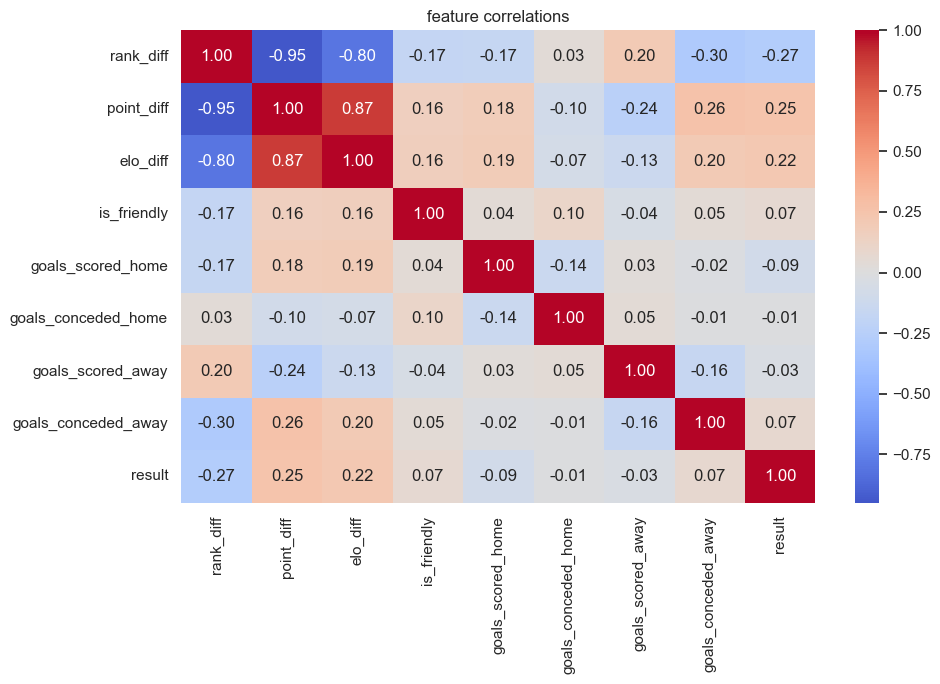

In [6]:
# correlation heatmap — shows which features are most related to the outcome
plt.figure(figsize=(10, 7))
sns.heatmap(df_model.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('feature correlations')
plt.tight_layout()
plt.show()

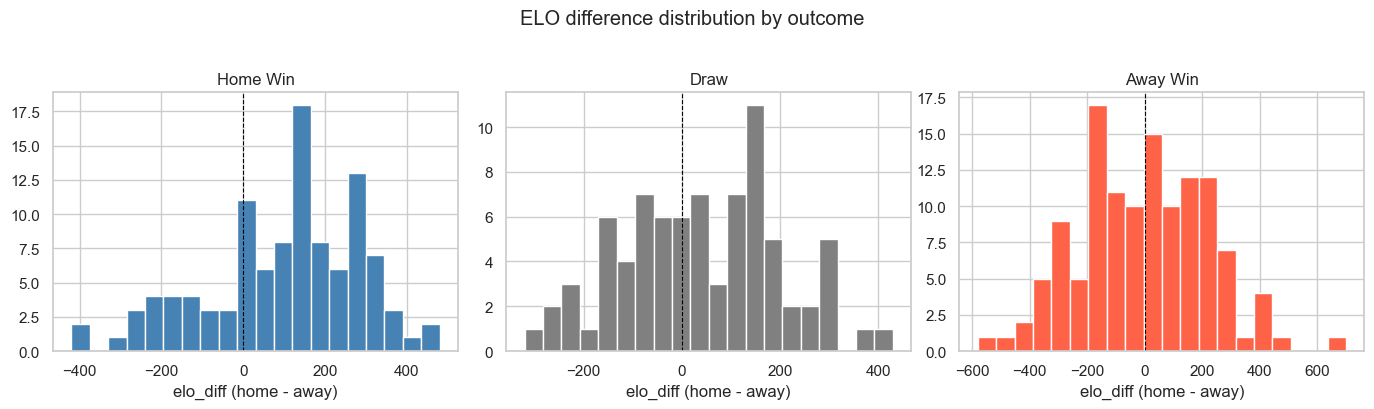

In [7]:
# elo_diff vs result — our strongest single predictor
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

labels = {1: 'Home Win', 0: 'Draw', -1: 'Away Win'}
colors = ['steelblue', 'grey', 'tomato']

for ax, (result, label), color in zip(axes, labels.items(), colors):
    subset = df_model[df_model['result'] == result]['elo_diff']
    ax.hist(subset, bins=20, color=color, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('elo_diff (home - away)')
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.suptitle('ELO difference distribution by outcome', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# save for use in the modelling notebooks
df_model.to_csv(PROCESSED / 'model_features.csv', index=False)
print('saved model_features.csv')

saved model_features.csv
